# CA6002 Part 4 — Model Evaluation & Final Story

**Purpose.** This notebook independently evaluates the frozen Part 3 Random Forest outputs. It does **not** retrain the model. Instead, it:

1. loads the verified Part 3 evaluation artifacts;
2. independently recomputes and validates key metrics;
3. compares the contextual model with the majority-class baseline;
4. analyses class-level precision, recall and F1;
5. examines the normalised confusion matrix and prediction distribution;
6. documents limitations and produces reproducible Part 4 figures and outputs.

The target is the recorded arrest severity class: **Felony, Misdemeanor, or Violation**.

> Interpretation note: these data describe recorded NYPD arrest activity and model behaviour on those records. They should not be interpreted as estimates of the underlying incidence of crime or as causal evidence.

## 1. Setup and repository paths

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

def find_repo_root(start=None):
    """Find the repository root whether the notebook is run from repo root or notebooks/."""
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "outputs" / "part3").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find outputs/part3. Run this notebook inside the cloned "
        "ca6002-nypd-temporal-analysis repository."
    )

REPO_ROOT = find_repo_root()
PART3 = REPO_ROOT / "outputs" / "part3"
PART4 = REPO_ROOT / "outputs" / "part4"
FIGURES = REPO_ROOT / "figures" / "part4"

PART4.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Reading Part 3:", PART3)
print("Writing Part 4 outputs:", PART4)
print("Writing Part 4 figures:", FIGURES)

Repository root: /mnt/data/_part4_exec
Reading Part 3: /mnt/data/_part4_exec/outputs/part3
Writing Part 4 outputs: /mnt/data/_part4_exec/outputs/part4
Writing Part 4 figures: /mnt/data/_part4_exec/figures/part4


## 2. Load frozen Part 3 evaluation outputs

In [2]:
required_files = {
    "model_metrics": PART3 / "model_metrics.json",
    "classification_report": PART3 / "classification_report.csv",
    "confusion_matrix": PART3 / "confusion_matrix.csv",
    "leakage_comparison": PART3 / "leakage_comparison.csv",
}

missing = [str(path) for path in required_files.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required Part 3 files:\n" + "\n".join(missing))

with open(required_files["model_metrics"], "r", encoding="utf-8") as f:
    metrics = json.load(f)

report = pd.read_csv(required_files["classification_report"], index_col=0)
cm_raw = pd.read_csv(required_files["confusion_matrix"], index_col=0)
comparison = pd.read_csv(required_files["leakage_comparison"])

display(comparison)
display(report)
display(cm_raw)

,model,accuracy,macro_f1
0,Majority baseline,0.5903,0.2475
1,Contextual model,0.5915,0.4972
2,Leakage-augmented model,0.9963,0.9927


,precision,recall,f1-score,support
Felony,0.5339,0.6224,0.5748,11131
Misdemeanor,0.6955,0.5668,0.6246,16586
Violation,0.1807,0.7652,0.2923,379
accuracy,0.5915,0.5915,0.5915,0
macro avg,0.4701,0.6515,0.4972,28096
weighted avg,0.6246,0.5915,0.6004,28096


,predicted_Felony,predicted_Misdemeanor,predicted_Violation
recorded_F,6928,4048,155
recorded_M,6025,9401,1160
recorded_V,22,67,290


### Why use several metrics?

The test set is highly imbalanced: **Misdemeanor** is the majority class, while **Violation** is rare. A classifier can therefore achieve a deceptively reasonable accuracy by favouring the majority class.

For this reason, Part 4 reports:

- **Accuracy** — overall proportion correctly classified;
- **Balanced accuracy** — average recall across classes;
- **Macro F1** — gives each class equal weight;
- **Per-class precision / recall / F1** — reveals which classes are handled well or poorly.

## 3. Independent validation of the evaluation outputs

In [3]:
CLASSES = ["Felony", "Misdemeanor", "Violation"]

# Standardise confusion-matrix labels for analysis.
cm = cm_raw.copy()
cm.index = CLASSES
cm.columns = CLASSES
cm.index.name = "Actual"
cm.columns.name = "Predicted"

total_test = int(cm.to_numpy().sum())
actual_counts = cm.sum(axis=1)
predicted_counts = cm.sum(axis=0)

accuracy_recomputed = np.trace(cm.to_numpy()) / total_test

precision_recomputed = pd.Series(
    np.diag(cm.to_numpy()) / predicted_counts.to_numpy(),
    index=CLASSES,
    name="precision"
)
recall_recomputed = pd.Series(
    np.diag(cm.to_numpy()) / actual_counts.to_numpy(),
    index=CLASSES,
    name="recall"
)
f1_recomputed = (
    2 * precision_recomputed * recall_recomputed
    / (precision_recomputed + recall_recomputed)
).rename("f1")

macro_f1_recomputed = float(f1_recomputed.mean())
balanced_accuracy_recomputed = float(recall_recomputed.mean())
majority_baseline_recomputed = float(actual_counts.max() / total_test)

reported_classes = report.loc[CLASSES]

checks = {
    "Confusion matrix has 3 classes": cm.shape == (3, 3),
    "Test-set total matches report support": total_test == int(reported_classes["support"].sum()),
    "Row totals match class support": np.allclose(
        actual_counts.to_numpy(), reported_classes["support"].to_numpy()
    ),
    "Accuracy matches model_metrics.json": np.isclose(
        accuracy_recomputed, metrics["accuracy"], atol=1e-12
    ),
    "Balanced accuracy matches model_metrics.json": np.isclose(
        balanced_accuracy_recomputed, metrics["balanced_accuracy"], atol=1e-12
    ),
    "Macro F1 matches model_metrics.json": np.isclose(
        macro_f1_recomputed, metrics["macro_f1"], atol=1e-12
    ),
    "Per-class precision matches report": np.allclose(
        precision_recomputed.to_numpy(), reported_classes["precision"].to_numpy()
    ),
    "Per-class recall matches report": np.allclose(
        recall_recomputed.to_numpy(), reported_classes["recall"].to_numpy()
    ),
    "Per-class F1 matches report": np.allclose(
        f1_recomputed.to_numpy(), reported_classes["f1-score"].to_numpy()
    ),
    "Majority baseline matches reported baseline": np.isclose(
        majority_baseline_recomputed, metrics["majority_baseline_accuracy"], atol=1e-12
    ),
}

validation = pd.DataFrame(
    {"check": list(checks.keys()), "passed": list(checks.values())}
)

display(validation)

if not validation["passed"].all():
    failed = validation.loc[~validation["passed"], "check"].tolist()
    raise AssertionError("Validation failed: " + "; ".join(failed))

print(f"All {len(validation)} validation checks passed.")
print(f"Test-set size: {total_test:,}")

,check,passed
0,Confusion matrix has 3 classes,True
1,Test-set total matches report support,True
2,Row totals match class support,True
3,Accuracy matches model_metrics.json,True
4,Balanced accuracy matches model_metrics.json,True
5,Macro F1 matches model_metrics.json,True
6,Per-class precision matches report,True
7,Per-class recall matches report,True
8,Per-class F1 matches report,True
9,Majority baseline matches reported baseline,True


All 10 validation checks passed.
Test-set size: 28,096


**Interpretation.** The validation step is deliberately separate from Part 3 modelling. It checks that the confusion matrix, class supports, summary metrics and baseline all reconcile mathematically before any Part 4 visualisation is produced.

## 4. Model vs majority-class baseline

In [4]:
baseline_row = comparison.loc[comparison["model"].eq("Majority baseline")].iloc[0]
model_row = comparison.loc[comparison["model"].eq("Contextual model")].iloc[0]

baseline_accuracy = float(baseline_row["accuracy"])
model_accuracy = float(model_row["accuracy"])
baseline_macro_f1 = float(baseline_row["macro_f1"])
model_macro_f1 = float(model_row["macro_f1"])

evaluation_summary = pd.DataFrame({
    "metric": ["Accuracy", "Macro F1"],
    "Majority Baseline": [baseline_accuracy, baseline_macro_f1],
    "Random Forest": [model_accuracy, model_macro_f1],
})
display(evaluation_summary)

accuracy_gain_pp = (model_accuracy - baseline_accuracy) * 100
macro_f1_gain = model_macro_f1 - baseline_macro_f1
macro_f1_relative_gain = macro_f1_gain / baseline_macro_f1

print(f"Accuracy gain: {accuracy_gain_pp:.3f} percentage points")
print(f"Macro F1 absolute gain: {macro_f1_gain:.3f}")
print(f"Macro F1 relative gain: {macro_f1_relative_gain:.1%}")

,metric,Majority Baseline,Random Forest
0,Accuracy,0.5903,0.5915
1,Macro F1,0.2475,0.4972


Accuracy gain: 0.117 percentage points
Macro F1 absolute gain: 0.250
Macro F1 relative gain: 100.9%


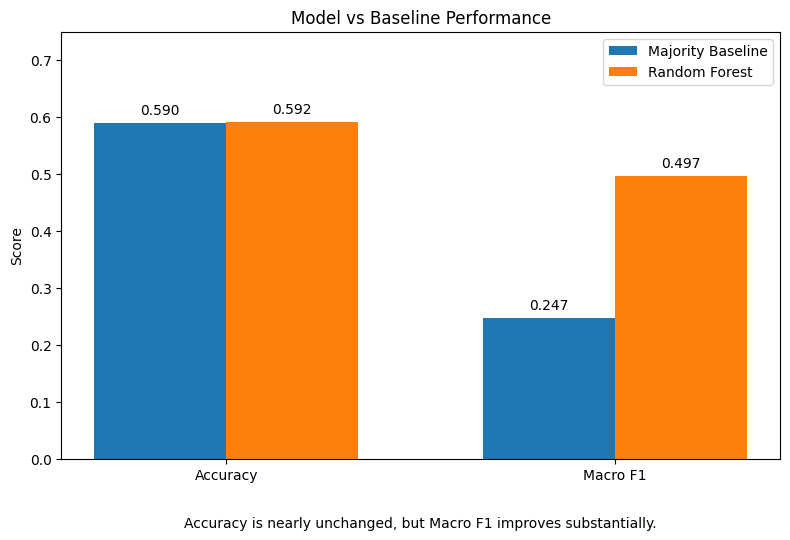

In [5]:
# Figure 1 — Model vs baseline
plot_df = evaluation_summary.set_index("metric")
x = np.arange(len(plot_df.index))
width = 0.34

fig, ax = plt.subplots(figsize=(8, 5.5))
bars1 = ax.bar(x - width/2, plot_df["Majority Baseline"], width, label="Majority Baseline")
bars2 = ax.bar(x + width/2, plot_df["Random Forest"], width, label="Random Forest")

ax.set_title("Model vs Baseline Performance")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.set_ylim(0, 0.75)
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.3f}",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
        )

ax.text(
    0.5, -0.16,
    "Accuracy is nearly unchanged, but Macro F1 improves substantially.",
    transform=ax.transAxes,
    ha="center",
)

plt.tight_layout()
fig.savefig(FIGURES / "model_vs_baseline.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURES / "model_vs_baseline.svg", format="svg", bbox_inches="tight")
plt.show()

### Finding

The Random Forest achieves almost the same raw accuracy as the majority-class baseline. However, the **Macro F1 score is substantially higher**, showing that the model performs much better when all three severity classes are weighted equally.

This is why accuracy alone would give an incomplete account of model performance.

## 5. Class-level performance

In [6]:
class_performance = reported_classes[["precision", "recall", "f1-score", "support"]].copy()
class_performance = class_performance.rename(columns={"f1-score": "f1"})
display(class_performance)

,precision,recall,f1,support
Felony,0.5339,0.6224,0.5748,11131
Misdemeanor,0.6955,0.5668,0.6246,16586
Violation,0.1807,0.7652,0.2923,379


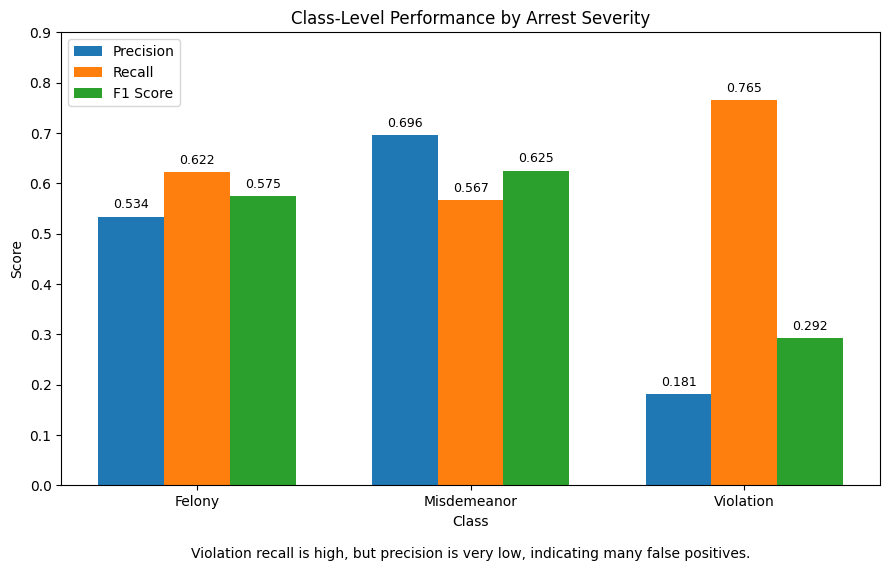

In [7]:
# Figure 2 — Precision, Recall and F1 by class
x = np.arange(len(CLASSES))
width = 0.24

fig, ax = plt.subplots(figsize=(9, 5.8))
bars1 = ax.bar(x - width, class_performance["precision"], width, label="Precision")
bars2 = ax.bar(x, class_performance["recall"], width, label="Recall")
bars3 = ax.bar(x + width, class_performance["f1"], width, label="F1 Score")

ax.set_title("Class-Level Performance by Arrest Severity")
ax.set_ylabel("Score")
ax.set_xlabel("Class")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylim(0, 0.9)
ax.legend()

for bars in (bars1, bars2, bars3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.3f}",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.text(
    0.5, -0.16,
    "Violation recall is high, but precision is very low, indicating many false positives.",
    transform=ax.transAxes,
    ha="center",
)

plt.tight_layout()
fig.savefig(FIGURES / "class_performance.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURES / "class_performance.svg", format="svg", bbox_inches="tight")
plt.show()

### Finding

The three classes are not equally well predicted.

- **Misdemeanor** has the strongest F1 score of the three classes.
- **Felony** has moderate precision and recall.
- **Violation** has high recall but very low precision.

The Violation result is especially important: high recall means many true Violation records are found, while low precision means a large share of predicted Violations are false positives.

## 6. Normalised confusion matrix and error structure

In [8]:
cm_normalised = cm.div(cm.sum(axis=1), axis=0)
display((cm_normalised * 100).round(2))

Predicted,Felony,Misdemeanor,Violation
Actual,,,
Felony,62.2400,36.3700,1.3900
Misdemeanor,36.3300,56.6800,6.9900
Violation,5.8000,17.6800,76.5200


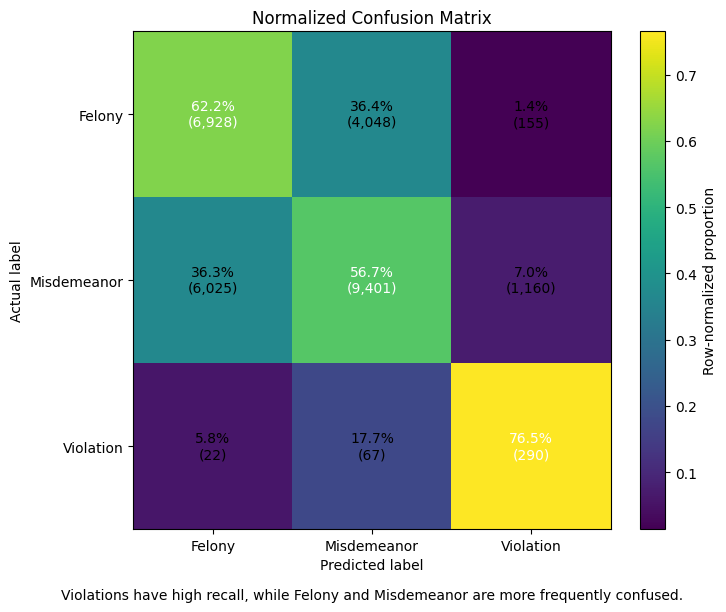

In [9]:
# Figure 3 — Row-normalised confusion matrix
fig, ax = plt.subplots(figsize=(7.5, 6.2))
im = ax.imshow(cm_normalised.to_numpy(), aspect="auto")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Row-normalized proportion")

ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_xticks(np.arange(len(CLASSES)))
ax.set_yticks(np.arange(len(CLASSES)))
ax.set_xticklabels(CLASSES)
ax.set_yticklabels(CLASSES)

threshold = cm_normalised.to_numpy().max() / 2
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        value = cm_normalised.iloc[i, j]
        raw = int(cm.iloc[i, j])
        ax.text(
            j, i,
            f"{value * 100:.1f}%\n({raw:,})",
            ha="center",
            va="center",
            color="white" if value > threshold else "black",
            fontsize=10,
        )

ax.text(
    0.5, -0.14,
    "Violations have high recall, while Felony and Misdemeanor are more frequently confused.",
    transform=ax.transAxes,
    ha="center",
)

plt.tight_layout()
fig.savefig(FIGURES / "normalized_confusion_matrix.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURES / "normalized_confusion_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

### Error analysis

The largest confusion occurs between **Felony** and **Misdemeanor**:

- a substantial share of actual Felonies are classified as Misdemeanors;
- a substantial share of actual Misdemeanors are classified as Felonies.

Violation behaves differently: its recall is comparatively high, but that result must be interpreted together with its low precision and the predicted class distribution in the next section.

## 7. Actual vs predicted class distribution

In [10]:
prediction_distribution = pd.DataFrame({
    "class": CLASSES,
    "actual": actual_counts.to_numpy(dtype=int),
    "predicted": predicted_counts.to_numpy(dtype=int),
})
prediction_distribution["predicted_minus_actual"] = (
    prediction_distribution["predicted"] - prediction_distribution["actual"]
)
prediction_distribution["predicted_to_actual_ratio"] = (
    prediction_distribution["predicted"] / prediction_distribution["actual"]
)

display(prediction_distribution)

violation_ratio = float(
    prediction_distribution.loc[
        prediction_distribution["class"].eq("Violation"),
        "predicted_to_actual_ratio"
    ].iloc[0]
)
print(f"Violation predicted-to-actual ratio: {violation_ratio:.2f}x")

,class,actual,predicted,predicted_minus_actual,predicted_to_actual_ratio
0,Felony,11131,12975,1844,1.1657
1,Misdemeanor,16586,13516,-3070,0.8149
2,Violation,379,1605,1226,4.2348


Violation predicted-to-actual ratio: 4.23x


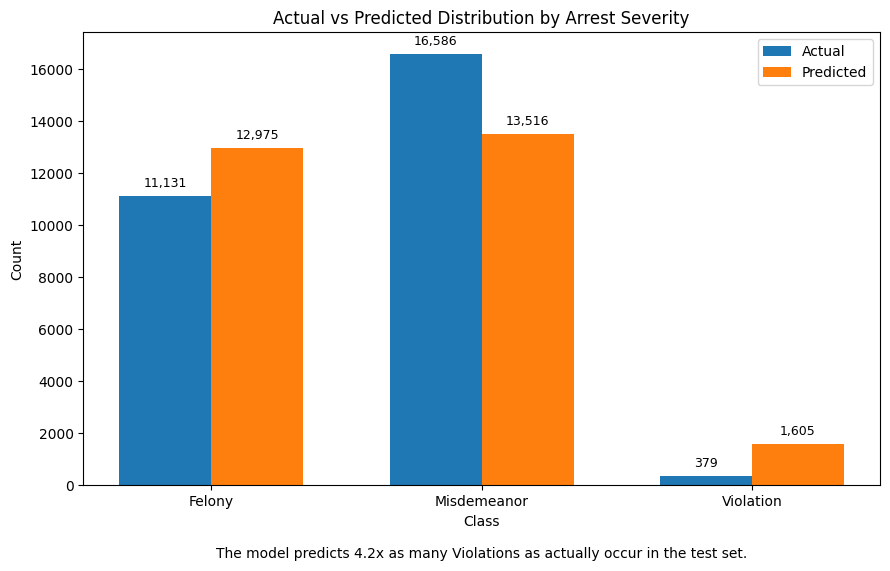

In [11]:
# Figure 4 — Actual vs predicted counts
x = np.arange(len(CLASSES))
width = 0.34

fig, ax = plt.subplots(figsize=(9, 5.8))
bars1 = ax.bar(x - width/2, prediction_distribution["actual"], width, label="Actual")
bars2 = ax.bar(x + width/2, prediction_distribution["predicted"], width, label="Predicted")

ax.set_title("Actual vs Predicted Distribution by Arrest Severity")
ax.set_ylabel("Count")
ax.set_xlabel("Class")
ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.legend()

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{int(h):,}",
            xy=(bar.get_x() + bar.get_width()/2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.text(
    0.5, -0.16,
    f"The model predicts {violation_ratio:.1f}x as many Violations as actually occur in the test set.",
    transform=ax.transAxes,
    ha="center",
)

plt.tight_layout()
fig.savefig(FIGURES / "actual_vs_predicted_distribution.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURES / "actual_vs_predicted_distribution.svg", format="svg", bbox_inches="tight")
plt.show()

### Finding

The model substantially **over-predicts the minority Violation class**. This explains the unusual combination of:

- high Violation recall; and
- very low Violation precision.

The model catches many of the true Violations, but it does so by assigning the Violation label to many records that actually belong to other classes.

## 8. Leakage sanity check

In [12]:
display(comparison)

contextual_accuracy = float(
    comparison.loc[comparison["model"].eq("Contextual model"), "accuracy"].iloc[0]
)
leakage_accuracy = float(
    comparison.loc[comparison["model"].eq("Leakage-augmented model"), "accuracy"].iloc[0]
)

print(f"Contextual model accuracy: {contextual_accuracy:.2%}")
print(f"Leakage-augmented accuracy: {leakage_accuracy:.2%}")
print(
    "Increase after adding leakage-prone features: "
    f"{(leakage_accuracy-contextual_accuracy)*100:.2f} percentage points"
)

,model,accuracy,macro_f1
0,Majority baseline,0.5903,0.2475
1,Contextual model,0.5915,0.4972
2,Leakage-augmented model,0.9963,0.9927


Contextual model accuracy: 59.15%
Leakage-augmented accuracy: 99.63%
Increase after adding leakage-prone features: 40.48 percentage points


### Why the leakage result matters

The near-perfect performance of the leakage-augmented model is **not** evidence that it is the better analytical model. Charge- and offence-related variables can reveal the target classification directly or indirectly.

The contextual model intentionally excludes these leakage-prone fields. Its lower performance is therefore more meaningful for the stated question: **how much predictive information is available from contextual characteristics alone?**

This experiment illustrates an important evaluation principle: **higher accuracy is not always more valid accuracy**.

## 9. Export reproducible Part 4 outputs

In [13]:
# Structured CSV outputs
evaluation_summary.to_csv(PART4 / "evaluation_summary.csv", index=False)
class_performance.to_csv(PART4 / "class_performance.csv")
cm_normalised.to_csv(PART4 / "normalized_confusion_matrix.csv")
prediction_distribution.to_csv(PART4 / "prediction_distribution.csv", index=False)
validation.to_csv(PART4 / "validation_checks.csv", index=False)

# Human-readable validation report
validation_lines = [
    "# Part 4 Validation Report",
    "",
    f"- Test-set size: **{total_test:,}**",
    f"- Validation checks passed: **{int(validation['passed'].sum())}/{len(validation)}**",
    "",
]
for _, row in validation.iterrows():
    validation_lines.append(
        f"- {'PASS' if row['passed'] else 'FAIL'} — {row['check']}"
    )

(PART4 / "validation_report.md").write_text(
    "\n".join(validation_lines) + "\n",
    encoding="utf-8"
)

# Human-readable key findings
key_findings_lines = [
    "# Part 4 — Model Evaluation & Final Story",
    "",
    "## 1. Model vs baseline",
    f"- Majority-class baseline accuracy: **{baseline_accuracy:.2%}**",
    f"- Random Forest accuracy: **{model_accuracy:.2%}**",
    f"- Accuracy improvement: **{accuracy_gain_pp:.3f} percentage points**",
    f"- Majority baseline Macro F1: **{baseline_macro_f1:.3f}**",
    f"- Random Forest Macro F1: **{model_macro_f1:.3f}**",
    f"- Macro F1 absolute improvement: **{macro_f1_gain:.3f}**",
    "",
    "Raw accuracy barely changes, but Macro F1 improves substantially. "
    "The contextual model is therefore more useful than the majority baseline "
    "for balanced recognition across all three classes, even though overall accuracy is almost unchanged.",
    "",
    "## 2. Class-level performance",
    f"- Felony — precision **{class_performance.loc['Felony','precision']:.3f}**, "
    f"recall **{class_performance.loc['Felony','recall']:.3f}**, "
    f"F1 **{class_performance.loc['Felony','f1']:.3f}**",
    f"- Misdemeanor — precision **{class_performance.loc['Misdemeanor','precision']:.3f}**, "
    f"recall **{class_performance.loc['Misdemeanor','recall']:.3f}**, "
    f"F1 **{class_performance.loc['Misdemeanor','f1']:.3f}**",
    f"- Violation — precision **{class_performance.loc['Violation','precision']:.3f}**, "
    f"recall **{class_performance.loc['Violation','recall']:.3f}**, "
    f"F1 **{class_performance.loc['Violation','f1']:.3f}**",
    "",
    "Violation has high recall but very low precision, indicating a large number "
    "of false-positive Violation predictions.",
    "",
    "## 3. Error structure",
    "Felony and Misdemeanor are frequently confused with each other.",
    f"The model predicts **{int(prediction_distribution.loc[prediction_distribution['class'].eq('Violation'),'predicted'].iloc[0]):,}** "
    f"Violation records compared with only **{int(prediction_distribution.loc[prediction_distribution['class'].eq('Violation'),'actual'].iloc[0]):,}** "
    f"actual Violation records — approximately **{violation_ratio:.1f}x** as many.",
    "",
    "## 4. Leakage sanity check",
    f"- Contextual model accuracy: **{contextual_accuracy:.2%}**",
    f"- Leakage-augmented accuracy: **{leakage_accuracy:.2%}**",
    "",
    "The near-perfect leakage-augmented result is intentionally not treated as "
    "the preferred model because offence/charge-related fields can reveal the target.",
    "",
    "## 5. Final interpretation",
    "Contextual characteristics contain measurable predictive information about "
    "recorded arrest severity, but they do not reliably determine whether an arrest "
    "is recorded as Felony, Misdemeanor or Violation.",
    "",
    "These results describe model behaviour on recorded NYPD arrests and should not "
    "be interpreted as causal relationships or as estimates of underlying crime incidence.",
]

(PART4 / "key_findings.md").write_text(
    "\n".join(key_findings_lines) + "\n",
    encoding="utf-8"
)

limitations_lines = [
    "# Part 4 — Evaluation Limitations",
    "",
    "1. **Severe class imbalance.** Violation is rare in the test set, making raw accuracy an incomplete evaluation measure.",
    "2. **Accuracy can be misleading.** The majority-class baseline already achieves high accuracy because Misdemeanor dominates the test set.",
    "3. **Minority-class trade-off.** Violation recall is high, but precision is low, so the model generates many false positives.",
    "4. **Context is incomplete.** Contextual variables alone cannot reliably determine legal severity.",
    "5. **Predictive association is not causality.** Model performance and feature contributions do not demonstrate causal relationships.",
    "6. **Arrest data are not crime incidence data.** Results describe recorded NYPD enforcement activity, not the true underlying rate of crime.",
    "7. **Leakage-prone variables are deliberately excluded.** Adding charge/offence information produces near-perfect performance but changes the meaning of the prediction task.",
]

(PART4 / "limitations.md").write_text(
    "\n".join(limitations_lines) + "\n",
    encoding="utf-8"
)

print("Part 4 outputs written to:", PART4)
print("Part 4 figures written to:", FIGURES)

Part 4 outputs written to: /mnt/data/_part4_exec/outputs/part4
Part 4 figures written to: /mnt/data/_part4_exec/figures/part4


## 10. Final evaluation story

The evaluation supports a nuanced conclusion:

1. **Overall accuracy alone does not show a meaningful improvement over majority-class guessing.**
2. **Macro F1 shows that the model is substantially better at distributing predictive performance across the three classes.**
3. **Felony and Misdemeanor are frequently confused.**
4. **Violation is aggressively over-predicted, producing high recall but poor precision.**
5. **Contextual information contains predictive signal, but it is not sufficient to determine recorded arrest severity reliably.**
6. **Near-perfect performance obtained with charge/offence variables is a leakage warning, not a reason to prefer that model.**

### Final project framing

The broader project should describe patterns in **recorded arrests and enforcement activity**, not make claims about the underlying incidence of crime. Predictive results should likewise be interpreted as associations in this dataset rather than causal conclusions.